# ***Next Word Predictor using LSTM RNN***

*# Hamlet dataset (brief summary):*

#* The Hamlet dataset typically refers to the text corpus derived from Hamlet, *italicized text* *italicized text* *one of the most famous plays by William Shakespeare. In data science and NLP, *italicized text* this dataset is used as a literary text dataset for tasks *like text analysis, language modeling, sentiment analysis, and character* interaction studies. *italicized text* *italicized text*

In [ ]:
!pip install nltk

In [ ]:
## data collection
import nltk
nltk.download('gutenberg')
from nltk.corpus import gutenberg
import pandas as pd

[nltk_data] Downloading package gutenberg to /root/nltk_data...
[nltk_data]   Package gutenberg is already up-to-date!


In [ ]:
## load our dataset
data = gutenberg.raw('shakespeare-hamlet.txt')

In [ ]:
## saving our dataset into a .txt file

with open('hamlet.txt' , 'w') as file:
  file.write(data)

In [ ]:
## Data preprocessing

import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer   ## to convert text into vectors
from tensorflow.keras.preprocessing.sequence import pad_sequences   # to make sure that every vector is of same length
from sklearn.model_selection import train_test_split

In [ ]:
## apyling tokenizer to our dataset

with open('hamlet.txt' , 'r') as file:
  text = file.read().lower()

In [ ]:
text

"[the tragedie of hamlet by william shakespeare 1599]\n\n\nactus primus. scoena prima.\n\nenter barnardo and francisco two centinels.\n\n  barnardo. who's there?\n  fran. nay answer me: stand & vnfold\nyour selfe\n\n   bar. long liue the king\n\n   fran. barnardo?\n  bar. he\n\n   fran. you come most carefully vpon your houre\n\n   bar. 'tis now strook twelue, get thee to bed francisco\n\n   fran. for this releefe much thankes: 'tis bitter cold,\nand i am sicke at heart\n\n   barn. haue you had quiet guard?\n  fran. not a mouse stirring\n\n   barn. well, goodnight. if you do meet horatio and\nmarcellus, the riuals of my watch, bid them make hast.\nenter horatio and marcellus.\n\n  fran. i thinke i heare them. stand: who's there?\n  hor. friends to this ground\n\n   mar. and leige-men to the dane\n\n   fran. giue you good night\n\n   mar. o farwel honest soldier, who hath relieu'd you?\n  fra. barnardo ha's my place: giue you goodnight.\n\nexit fran.\n\n  mar. holla barnardo\n\n   bar. 

In [ ]:
## Tokenizing our text
tokenizer = Tokenizer()

tokenizer.fit_on_texts([text])

In [ ]:
total_words = len(tokenizer.word_index) + 1
print("Total Word in the dataset after tokenization : " , total_words)

Total Word in the dataset after tokenization :  4818


In [ ]:
tokenizer.word_index

{'the': 1,
 'and': 2,
 'to': 3,
 'of': 4,
 'i': 5,
 'you': 6,
 'a': 7,
 'my': 8,
 'it': 9,
 'in': 10,
 'that': 11,
 'ham': 12,
 'is': 13,
 'not': 14,
 'his': 15,
 'this': 16,
 'with': 17,
 'your': 18,
 'but': 19,
 'for': 20,
 'me': 21,
 'lord': 22,
 'as': 23,
 'what': 24,
 'he': 25,
 'be': 26,
 'so': 27,
 'him': 28,
 'haue': 29,
 'king': 30,
 'will': 31,
 'no': 32,
 'our': 33,
 'we': 34,
 'on': 35,
 'are': 36,
 'if': 37,
 'all': 38,
 'then': 39,
 'shall': 40,
 'by': 41,
 'thou': 42,
 'come': 43,
 'or': 44,
 'hamlet': 45,
 'good': 46,
 'do': 47,
 'hor': 48,
 'her': 49,
 'let': 50,
 'now': 51,
 'thy': 52,
 'how': 53,
 'more': 54,
 'they': 55,
 'from': 56,
 'enter': 57,
 'at': 58,
 'was': 59,
 'oh': 60,
 'like': 61,
 'most': 62,
 'there': 63,
 'well': 64,
 'know': 65,
 'selfe': 66,
 'would': 67,
 'them': 68,
 'loue': 69,
 'may': 70,
 "'tis": 71,
 'vs': 72,
 'sir': 73,
 'qu': 74,
 'which': 75,
 'did': 76,
 'why': 77,
 'laer': 78,
 'giue': 79,
 'thee': 80,
 'ile': 81,
 'must': 82,
 'hath': 

In [ ]:
### Logic behind word_index = {'the' : 1} means 'the' is the most common word / most frequent word of the dataset so it's rank is 1 , similarly 'and' : 2 and 'to' : 3 are the next most frequent words

### So basically the values of each word is the rank given to them based on their frequency , most frequent word -----> more rank (less value / index).

In [ ]:
## Now we have to create and input and output sequence for our dataset

# Line - by - Line Approach

# input sequence
input_seq = []
for line in text.split('\n'):   # we process the text line by line based on the '\n' means a new line and it is stored in the from of list .
  token_list = tokenizer.texts_to_sequences([line])[0]  # now we convert each line of the text into a list of integers based on word_index
  for i in range(1 , len(token_list)):   # we loop through the tokens and append each token into input_seq
    n_gram_sequence = token_list[: i + 1]
    input_seq.append(n_gram_sequence)

In [ ]:
print('Total Sequences : ' , len(input_seq))

Total Sequences :  25732


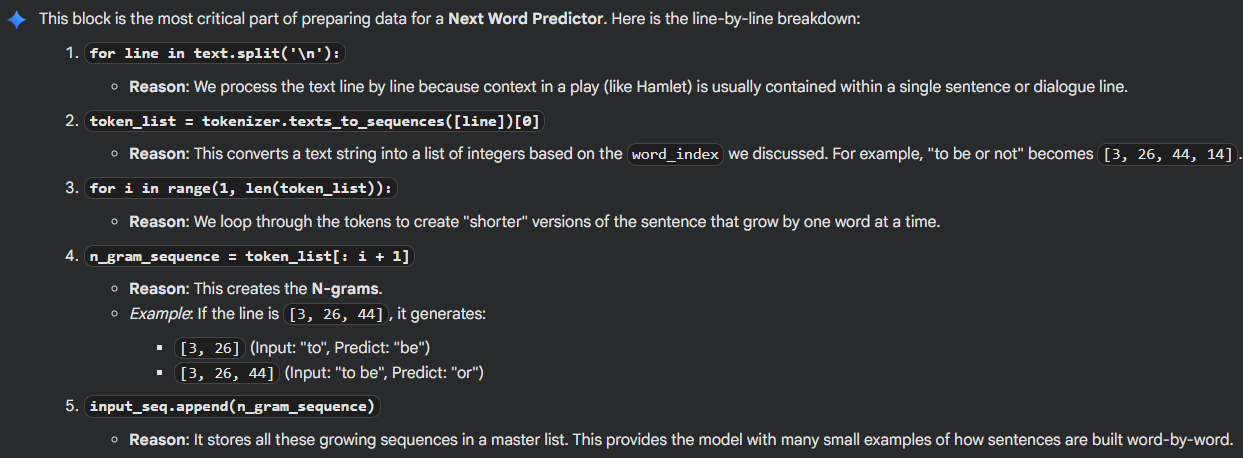

In [ ]:
input_seq

[[1, 687],
 [1, 687, 4],
 [1, 687, 4, 45],
 [1, 687, 4, 45, 41],
 [1, 687, 4, 45, 41, 1886],
 [1, 687, 4, 45, 41, 1886, 1887],
 [1, 687, 4, 45, 41, 1886, 1887, 1888],
 [1180, 1889],
 [1180, 1889, 1890],
 [1180, 1889, 1890, 1891],
 [57, 407],
 [57, 407, 2],
 [57, 407, 2, 1181],
 [57, 407, 2, 1181, 177],
 [57, 407, 2, 1181, 177, 1892],
 [407, 1182],
 [407, 1182, 63],
 [408, 162],
 [408, 162, 377],
 [408, 162, 377, 21],
 [408, 162, 377, 21, 247],
 [408, 162, 377, 21, 247, 882],
 [18, 66],
 [451, 224],
 [451, 224, 248],
 [451, 224, 248, 1],
 [451, 224, 248, 1, 30],
 [408, 407],
 [451, 25],
 [408, 6],
 [408, 6, 43],
 [408, 6, 43, 62],
 [408, 6, 43, 62, 1893],
 [408, 6, 43, 62, 1893, 96],
 [408, 6, 43, 62, 1893, 96, 18],
 [408, 6, 43, 62, 1893, 96, 18, 566],
 [451, 71],
 [451, 71, 51],
 [451, 71, 51, 1894],
 [451, 71, 51, 1894, 567],
 [451, 71, 51, 1894, 567, 378],
 [451, 71, 51, 1894, 567, 378, 80],
 [451, 71, 51, 1894, 567, 378, 80, 3],
 [451, 71, 51, 1894, 567, 378, 80, 3, 273],
 [451, 71

In [ ]:
import numpy as np

# Alternative optimized approach using a flattened sequence
# This version is faster as it reduces the overhead of re-splitting and re-tokenizing lines

full_token_list = tokenizer.texts_to_sequences([text])[0]

# Create N-gram sequences using list comprehension (much faster in Python)
input_seq2 = [full_token_list[:i+1] for i in range(1, len(full_token_list))]

print(f"Total sequences generated: {len(input_seq2)}")
print(f"Example sequence: {input_seq2[0]}")

Total sequences generated: 29697
Example sequence: [1, 687]


In [ ]:
input_seq

[[1, 687],
 [1, 687, 4],
 [1, 687, 4, 45],
 [1, 687, 4, 45, 41],
 [1, 687, 4, 45, 41, 1886],
 [1, 687, 4, 45, 41, 1886, 1887],
 [1, 687, 4, 45, 41, 1886, 1887, 1888],
 [1180, 1889],
 [1180, 1889, 1890],
 [1180, 1889, 1890, 1891],
 [57, 407],
 [57, 407, 2],
 [57, 407, 2, 1181],
 [57, 407, 2, 1181, 177],
 [57, 407, 2, 1181, 177, 1892],
 [407, 1182],
 [407, 1182, 63],
 [408, 162],
 [408, 162, 377],
 [408, 162, 377, 21],
 [408, 162, 377, 21, 247],
 [408, 162, 377, 21, 247, 882],
 [18, 66],
 [451, 224],
 [451, 224, 248],
 [451, 224, 248, 1],
 [451, 224, 248, 1, 30],
 [408, 407],
 [451, 25],
 [408, 6],
 [408, 6, 43],
 [408, 6, 43, 62],
 [408, 6, 43, 62, 1893],
 [408, 6, 43, 62, 1893, 96],
 [408, 6, 43, 62, 1893, 96, 18],
 [408, 6, 43, 62, 1893, 96, 18, 566],
 [451, 71],
 [451, 71, 51],
 [451, 71, 51, 1894],
 [451, 71, 51, 1894, 567],
 [451, 71, 51, 1894, 567, 378],
 [451, 71, 51, 1894, 567, 378, 80],
 [451, 71, 51, 1894, 567, 378, 80, 3],
 [451, 71, 51, 1894, 567, 378, 80, 3, 273],
 [451, 71

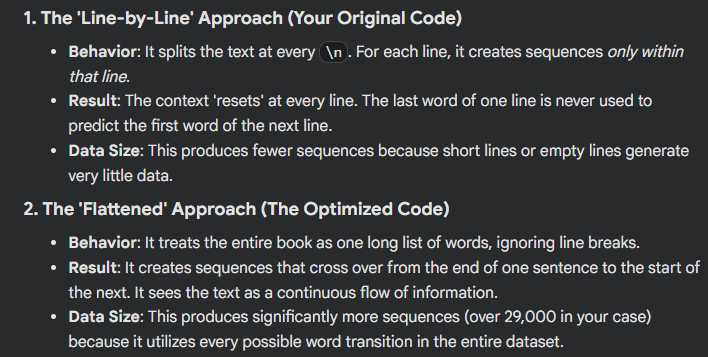

----------------------------------------------------------------------------------------------------------------------------------------------------------------

***So if we want the model to learn specific 'verse' or 'poetic' , we will use the first approach***

In [ ]:
## Now we will apply pad_sequences
# We use the line-by-line sequences (input_seq)
max_sequence_len = max([len(x) for x in input_seq])
print(f"Maximum sequence length: {max_sequence_len}")

Maximum sequence length: 14


In [ ]:
## Now we will pad all our input sequences with zeros so that teh sentences are of same length
input_seq = np.array(pad_sequences(input_seq , maxlen = max_sequence_len , padding = 'pre'))

print('Shape of input sequnces : ' , input_seq.shape)

Shape of input sequnces :  (25732, 14)


In [ ]:
print('Below is ou padded input sequnece:\n')
input_seq

Below is ou padded input sequnece:



array([[   0,    0,    0, ...,    0,    1,  687],
       [   0,    0,    0, ...,    1,  687,    4],
       [   0,    0,    0, ...,  687,    4,   45],
       ...,
       [   0,    0,    0, ...,    4,   45, 1047],
       [   0,    0,    0, ...,   45, 1047,    4],
       [   0,    0,    0, ..., 1047,    4,  193]], dtype=int32)

In [ ]:
## Now we divide our dataset into training and testing dataset

import tensorflow as tf

X  = input_seq[: , : -1]
#  : means take all rows (every sequnce)  &   : -1 means take all columns except last one
y = input_seq[: , -1]  # means we take the last word as our output or the next word that we are going to predict

In [ ]:
y

array([ 687,    4,   45, ..., 1047,    4,  193], dtype=int32)

In [ ]:
# We are One Hot Encoding our ' y ' so each word get it's own slot as 1 andrest all becoems 0
#  because we are treating next word predictor as a classification problem.

y = tf.keras.utils.to_categorical(y , num_classes = total_words)
y

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [ ]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
### Splitting or data into training and testing sets

X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 0.2)

In [ ]:
### TRaining our LSTM RNN

from tensorflow.keras.layers import Embedding , LSTM , Dense , Dropout
from tensorflow.keras.models import Sequential

In [ ]:
### Defining our model

model = Sequential()
# input_length is 13 because X has 13 columns (max_sequence_len - 1)
model.add(Embedding(total_words, 100, input_shape=(max_sequence_len - 1,)))
model.add(LSTM(units=150, return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(units=100))
model.add(Dense(total_words, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:103: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
### Compiling our model

# Fixed typo in 'accuracy'
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy', 'precision', 'recall'])

In [ ]:
model.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_9 (Embedding)         │ (None, 13, 100)        │       481,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 13, 150)        │       150,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 13, 150)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_12 (LSTM)                  │ (None, 100)            │       100,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4818)           │       486,618 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,219,418 (4.65 MB)

 Trainable params: 1,219,418 (4.65 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
### Now we start training our model

history = model.fit(X_train , y_train , epochs = 50 , validation_data = (X_test , y_test) , verbose = 1)

Epoch 1/50
644/644 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.0879 - loss: 5.5531 - precision: 0.7294 - recall: 0.0060 - val_accuracy: 0.0585 - val_loss: 7.1927 - val_precision: 0.4211 - val_recall: 0.0031
Epoch 2/50
644/644 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.0957 - loss: 5.4130 - precision: 0.7415 - recall: 0.0085 - val_accuracy: 0.0622 - val_loss: 7.3080 - val_precision: 0.3947 - val_recall: 0.0029
Epoch 3/50
644/644 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.1015 - loss: 5.2846 - precision: 0.7705 - recall: 0.0114 - val_accuracy: 0.0666 - val_loss: 7.4372 - val_precision: 0.3929 - val_recall: 0.0043
Epoch 4/50
644/644 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.1058 - loss: 5.1610 - precision: 0.7947 - recall: 0.0147 - val_accuracy: 0.0637 - val_loss: 7.5339 - val_precision: 0.3721 - val_recall: 0.0062
Epoch 5/50
644/644 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.1140 - loss: 5.0374 - precision: 0.8035 - recall: 0.0181 - val_accuracy: 0.0653 - val_los

In [ ]:
## Defining early stopping

from tensorflow.keras.callbacks import EarlyStopping
early = EarlyStopping(monitor = 'val_loss' , patience = 10 , restore_best_weights = True)

history2 = model.fit(X_train , y_train , epochs=100 , validation_data = (X_test , y_test) , callbacks = [early])

Epoch 1/100
644/644 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.5100 - loss: 2.1822 - precision: 0.9396 - recall: 0.2668 - val_accuracy: 0.0525 - val_loss: 12.4012 - val_precision: 0.1302 - val_recall: 0.0146
Epoch 2/100
644/644 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.5152 - loss: 2.1606 - precision: 0.9412 - recall: 0.2720 - val_accuracy: 0.0532 - val_loss: 12.4654 - val_precision: 0.1379 - val_recall: 0.0155
Epoch 3/100
644/644 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.5174 - loss: 2.1339 - precision: 0.9376 - recall: 0.2786 - val_accuracy: 0.0517 - val_loss: 12.5055 - val_precision: 0.1292 - val_recall: 0.0150
Epoch 4/100
644/644 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.5257 - loss: 2.1093 - precision: 0.9417 - recall: 0.2827 - val_accuracy: 0.0495 - val_loss: 12.5789 - val_precision: 0.1375 - val_recall: 0.0165
Epoch 5/100
644/644 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.5299 - loss: 2.0818 - precision: 0.9348 - recall: 0.2883 - val_accuracy: 0.0513

In [2]:
# Function to predict the next word
def predict_next_word(model , tokenizer ,input_text , max_sequnece_len):
  token_list = tokenizer.texts_to_sequences([input_text])[0]
  if len(token_list) >= max_sequence_len:
    token_list = token_list[-(max_sequence_len - 1) : ]
  token_list = pad_sequences([token_list] , maxlen = max_sequence_len - 1 , padding = 'pre')

  predicted = model.predict(token_list , verbose = 0)
  predicted_word_index = np.argmax(predicted , axis = 1)

  for word , index in tokenizer.word_index.items():
    if index == predicted_word_index:
      return word

  return None

In [3]:
input_text = "Mar. Horatio saies, 'tis but our"
print(f"Input Text : {input_text}")
max_sequence_len = model.input_shape[1] + 1
next_word = predict_next_word(model , tokenizer , input_text , max_sequence_len)
print(f"Next Word : {next_word}")

Input Text : Mar. Horatio saies, 'tis but our


NameError: name 'model' is not defined

In [ ]:
#### Now after training completed we save it

model.save('lstm_rnn_model.h5')

# saved inside /content/

In [1]:
### Saving our tokenizer
import pickle
with open('tokenizer.pickle', 'wb') as file:
    pickle.dump(tokenizer, file, protocol=pickle.HIGHEST_PROTOCOL)

NameError: name 'tokenizer' is not defined

In [1]:
from tensorflow.keras.models import load_model

# Load your old model
model = load_model('lstm_rnn_model.h5', compile=False)

# Save in new format
model.save('lstm_rnn_model.keras')

print("Model resaved successfully!")

Model resaved successfully!
